In [74]:
import pandas as pd
import numpy as np

In [75]:
df = pd.read_excel('Online Retail.xlsx')

In [76]:
# 1. Load data and check missing rows and duplicate data
print("Data shape:", df.shape)
print("\nFirst few rows:")
print(df.head())
print("\nData Info:")
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())
print("\nDuplicate rows count:", df.duplicated().sum())
print("\nDuplicate rows:")
print(df[df.duplicated(keep=False)].sort_values(by=list(df.columns)).head(10))

Data shape: (541909, 8)

First few rows:
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  

Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dt

In [77]:
# 2. Top 10 selling products based on quantity
top_10_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
print("Top 10 Selling Products by Quantity:")
print(top_10_products)

Top 10 Selling Products by Quantity:
Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     53847
JUMBO BAG RED RETROSPOT               47363
ASSORTED COLOUR BIRD ORNAMENT         36381
POPCORN HOLDER                        36334
PACK OF 72 RETROSPOT CAKE CASES       36039
WHITE HANGING HEART T-LIGHT HOLDER    35317
RABBIT NIGHT LIGHT                    30680
MINI PAINT SET VINTAGE                26437
PACK OF 12 LONDON TISSUES             26315
PACK OF 60 PINK PAISLEY CAKE CASES    24753
Name: Quantity, dtype: int64


In [78]:
# 3. Generate revenue column
df['Revenue'] = df['Quantity'] * df['UnitPrice']
print("Revenue column created")
print(df[['Quantity', 'UnitPrice', 'Revenue']].head())

Revenue column created
   Quantity  UnitPrice  Revenue
0         6       2.55    15.30
1         6       3.39    20.34
2         8       2.75    22.00
3         6       3.39    20.34
4         6       3.39    20.34


In [79]:
# 4. Calculate average order value by country
# AOV = Total Revenue / Total Number of Orders per country
aov_by_country = df.groupby('Country').agg({
    'Revenue': 'sum',
    'InvoiceNo': 'nunique'
}).reset_index()
aov_by_country.columns = ['Country', 'Total_Revenue', 'Total_Orders']
aov_by_country['AOV'] = aov_by_country['Total_Revenue'] / aov_by_country['Total_Orders']
aov_by_country = aov_by_country.sort_values('AOV', ascending=False)

print("Average Order Value by Country:")
print(aov_by_country.head(10))
print("\nHighest AOV Country:")
highest_aov_country = aov_by_country.iloc[0]
print(f"Country: {highest_aov_country['Country']}, AOV: {highest_aov_country['AOV']:.2f}")

Average Order Value by Country:
        Country  Total_Revenue  Total_Orders          AOV
24  Netherlands      284661.54           101  2818.431089
0     Australia      137077.27            69  1986.627101
21      Lebanon        1693.88             1  1693.880000
20        Japan       35340.62            28  1262.165000
4        Brazil        1143.60             1  1143.600000
28          RSA        1002.31             1  1002.310000
30    Singapore        9120.39            10   912.039000
9       Denmark       18768.14            21   893.720952
25       Norway       35163.46            40   879.086500
18       Israel        7907.82             9   878.646667

Highest AOV Country:
Country: Netherlands, AOV: 2818.43


In [80]:
# 5. Find and list all products bought together
# Group products by invoice to find which items were bought in the same transaction
products_by_invoice = df.groupby('InvoiceNo')['Description'].apply(list).reset_index()
products_by_invoice['num_items'] = products_by_invoice['Description'].apply(len)

# Filter invoices with more than 1 item
multi_item_invoices = products_by_invoice[products_by_invoice['num_items'] > 1]

print(f"Total invoices with multiple items: {len(multi_item_invoices)}")
print("\nSample of products bought together:")
for i, items in enumerate(multi_item_invoices['Description'].head(10)):
    print(f"Transaction {i+1}: {', '.join(set(items[:5]))}")  # Show unique items

# Find most common product pairs
from itertools import combinations
product_pairs = []
for items in multi_item_invoices['Description']:
    unique_items = list(set(items))
    for pair in combinations(unique_items, 2):
        product_pairs.append(tuple(sorted(pair)))

pair_counts = pd.Series(product_pairs).value_counts()
print("\nTop 10 Most Frequently Bought Together:")
print(pair_counts.head(10))

Total invoices with multiple items: 20059

Sample of products bought together:
Transaction 1: WHITE HANGING HEART T-LIGHT HOLDER, RED WOOLLY HOTTIE WHITE HEART., CREAM CUPID HEARTS COAT HANGER, KNITTED UNION FLAG HOT WATER BOTTLE, WHITE METAL LANTERN
Transaction 2: HAND WARMER RED POLKA DOT, HAND WARMER UNION JACK
Transaction 3: ASSORTED COLOUR BIRD ORNAMENT, IVORY KNITTED MUG COSY , POPPY'S PLAYHOUSE BEDROOM , FELTCRAFT PRINCESS CHARLOTTE DOLL, POPPY'S PLAYHOUSE KITCHEN
Transaction 4: BLUE COAT RACK PARIS FASHION, JAM MAKING SET WITH JARS, YELLOW COAT RACK PARIS FASHION, RED COAT RACK PARIS FASHION
Transaction 5: ALARM CLOCK BAKELIKE RED , ALARM CLOCK BAKELIKE PINK, ALARM CLOCK BAKELIKE GREEN, STARS GIFT TAPE , PANDA AND BUNNIES STICKER SHEET
Transaction 6: HAND WARMER RED POLKA DOT, HAND WARMER UNION JACK
Transaction 7: WHITE HANGING HEART T-LIGHT HOLDER, CREAM CUPID HEARTS COAT HANGER, RETRO COFFEE MUGS ASSORTED, EDWARDIAN PARASOL RED, WHITE METAL LANTERN
Transaction 8: WHITE HANGIN

In [81]:
# 6. Identify customers who purchased more than 10 items
customer_quantity = df.groupby('CustomerID')['Quantity'].sum().reset_index()
customer_quantity.columns = ['CustomerID', 'Total_Quantity']
high_volume_customers = customer_quantity[customer_quantity['Total_Quantity'] > 10].sort_values('Total_Quantity', ascending=False)

print(f"Number of customers who purchased more than 10 items: {len(high_volume_customers)}")
print("\nTop 20 High-Volume Customers:")
print(high_volume_customers.head(20))

Number of customers who purchased more than 10 items: 4286

Top 20 High-Volume Customers:
      CustomerID  Total_Quantity
1703     14646.0          196719
55       12415.0           77242
1895     14911.0           77180
3758     17450.0           69029
4233     18102.0           64122
3801     17511.0           63012
1005     13694.0           61803
1447     14298.0           58021
1345     14156.0           57025
3202     16684.0           49390
2192     15311.0           37720
3014     16422.0           32592
3722     17404.0           32324
2945     16333.0           32184
2722     16029.0           32148
568      13089.0           30787
1999     15061.0           28590
2537     15769.0           27660
4125     17949.0           27571
3704     17381.0           25646


Shopping Activity by Hour:
    Hour  Transactions  Total_Quantity  Total_Revenue
6     12          3962          823935    1362484.290
7     13          3369          676803    1177506.370
5     11          3165          637672    1147437.920
8     14          3137          571549    1095212.901
9     15          3069          609710    1189458.280
4     10          2961          684416    1329056.521
10    16          1952          312317     729140.820
3      9          1824          429366     766734.051
11    17          1205          156331     435444.111
2      8           624          158163     281840.860
12    18           333           60615     140574.480
13    19           219           32030      46324.990
1      7            31           15361      31009.320
14    20            28            8268      16020.370
0      6            22             -86       -497.350

Peak Shopping Hours (Top 5 by transactions):
   Hour  Transactions  Total_Quantity  Total_Revenue
6    12   

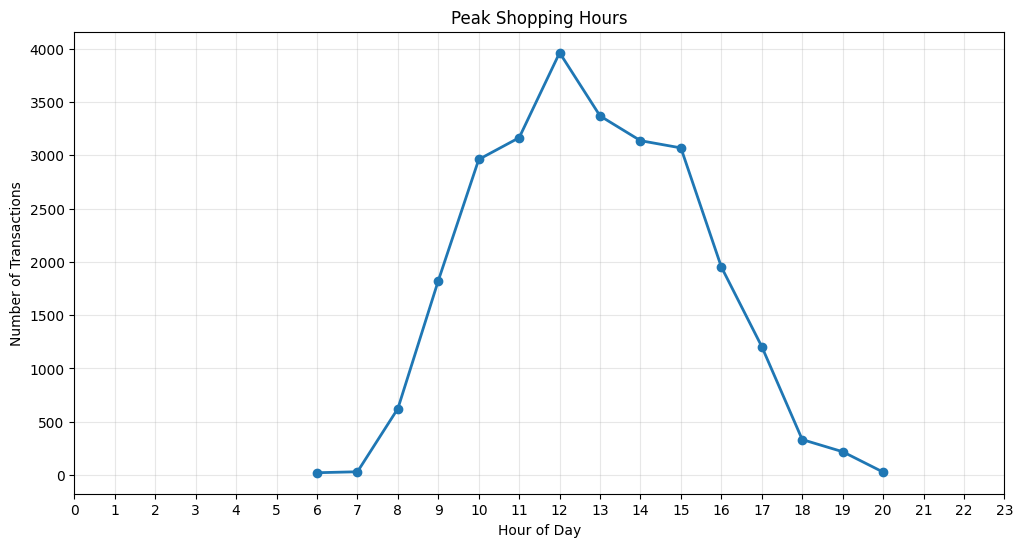

In [83]:
# 7. Find peak shopping hours of customers
# Convert InvoiceDate to datetime and extract hour
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Hour'] = df['InvoiceDate'].dt.hour

# Aggregate by hour
shopping_by_hour = df.groupby('Hour').agg({
    'InvoiceNo': 'nunique',  # Number of transactions
    'Quantity': 'sum',        # Total quantity sold
    'Revenue': 'sum'          # Total revenue
}).reset_index()
shopping_by_hour.columns = ['Hour', 'Transactions', 'Total_Quantity', 'Total_Revenue']
shopping_by_hour = shopping_by_hour.sort_values('Transactions', ascending=False)

print("Shopping Activity by Hour:")
print(shopping_by_hour)
print("\nPeak Shopping Hours (Top 5 by transactions):")
print(shopping_by_hour.head(5))

# Plot for visualization
import matplotlib.pyplot as plt
shopping_by_hour_sorted = shopping_by_hour.sort_values('Hour')
plt.figure(figsize=(12, 6))
plt.plot(shopping_by_hour_sorted['Hour'], shopping_by_hour_sorted['Transactions'], marker='o', linewidth=2)
plt.xlabel('Hour of Day')
plt.ylabel('Number of Transactions')
plt.title('Peak Shopping Hours')
plt.grid(True, alpha=0.3)
plt.xticks(range(0, 24))
plt.show()